#Task 1.1 — Load Data and Set Up a Baseline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

df = pd.read_excel('Practice_Dataset.xlsx')

# Regression target: monthly_salary
features = ['punch_count', 'hours_worked', 'satisfaction_score']
df_model = df[features + ['monthly_salary']].copy()

# Impute missing values (median) so learning_curve doesn't break on NaNs
imputer = SimpleImputer(strategy='median')
df_model[features + ['monthly_salary']] = imputer.fit_transform(df_model[features + ['monthly_salary']])

X = df_model[features]
y = df_model['monthly_salary']

#Task 1.2 — Plot a Learning Curve

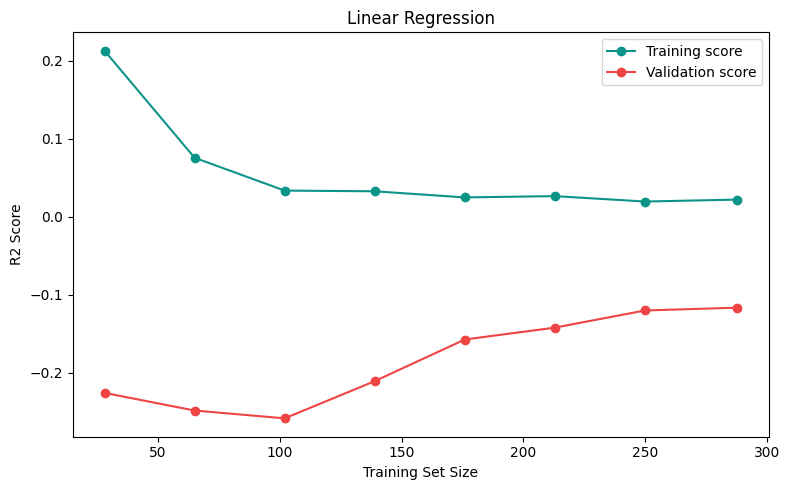

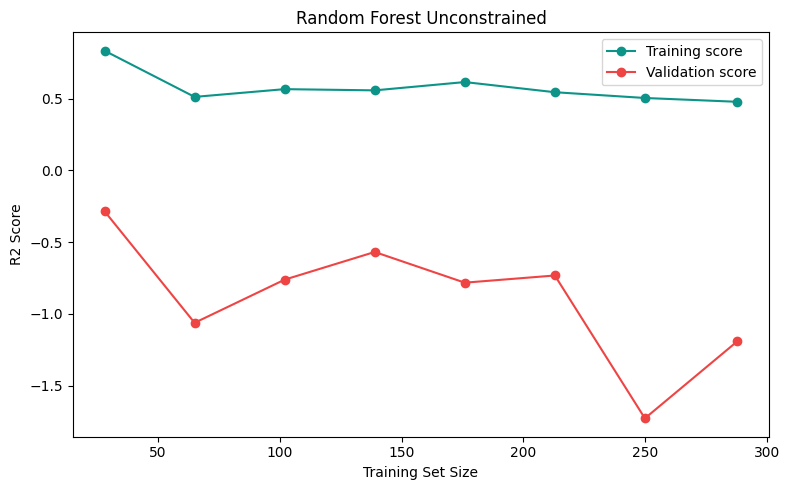

In [3]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='#0D9488', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', color='#EF4444', label='Validation score')
    plt.xlabel('Training Set Size')
    plt.ylabel('R2 Score')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'learning_curve_{title.replace(" ", "_")}.png', dpi=150)
    plt.show()
    return train_mean, val_mean

# A very simple model - likely to underfit
lr_train, lr_val = plot_learning_curve(LinearRegression(), X, y, 'Linear Regression')

# A very complex, unconstrained model - likely to overfit
rf_train, rf_val = plot_learning_curve(
    RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42),
    X, y, 'Random Forest Unconstrained'
)

#Task 1.3 — Diagnose the Pattern

In [4]:
# HOW TO READ A LEARNING CURVE:
#
# UNDERFITTING (high bias):
# - Both training AND validation scores are low
# - The two curves converge close together, but at a low score
# - Fix: more features, more complex model, less regularization
#
# OVERFITTING (high variance):
# - Training score is high, validation score is much lower
# - Large, persistent GAP between the two curves
# - Fix: more data, simpler model, more regularization, feature selection
#
# GOOD FIT:
# - Both curves converge to a similarly high score
# - Small gap between training and validation

lr_gap = lr_train[-1] - lr_val[-1]
rf_gap = rf_train[-1] - rf_val[-1]

print(f'Linear Regression: train={lr_train[-1]:.3f}, val={lr_val[-1]:.3f}, gap={lr_gap:.3f}')
print('- Linear Regression: underfit — both train and validation R2 are low '
      '(~0.02 and ~-0.12), the features barely explain salary variance.')

print(f'Random Forest (unconstrained): train={rf_train[-1]:.3f}, val={rf_val[-1]:.3f}, gap={rf_gap:.3f}')
print('- Random Forest (unconstrained): overfit — train R2 is much higher than '
      'validation R2 (~0.48 vs ~-1.19), a large persistent gap.')

Linear Regression: train=0.022, val=-0.116, gap=0.138
- Linear Regression: underfit — both train and validation R2 are low (~0.02 and ~-0.12), the features barely explain salary variance.
Random Forest (unconstrained): train=0.479, val=-1.191, gap=1.670
- Random Forest (unconstrained): overfit — train R2 is much higher than validation R2 (~0.48 vs ~-1.19), a large persistent gap.
